## Phiên bản được viết bằng Numba

In [16]:
import os
import sys
from pathlib import Path

In [17]:
current_path = Path().resolve()
while current_path.name != "APP-project":
    if current_path.parent == current_path:
        raise FileNotFoundError("❌ Không tìm thấy thư mục gốc 'APP-project'")
    current_path = current_path.parent

os.chdir(current_path)
# print(f"📂 Project root set to: {current_path}")

In [18]:
# !"D:\Download\Downloads\python.exe" -m pip install -r requirements_python311.txt

In [47]:
sys.path.append('Src')
from Src import func as func

import numpy as np
import matplotlib.pyplot as plt

from numpy.lib.stride_tricks import as_strided

import random
import math
import time

from numba import cuda, float32

import warnings
warnings.filterwarnings('ignore')

In [20]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Wed_Apr_17_19:36:51_Pacific_Daylight_Time_2024
Cuda compilation tools, release 12.5, V12.5.40
Build cuda_12.5.r12.5/compiler.34177558_0


In [21]:
!ptxas --version

ptxas: NVIDIA (R) Ptx optimizing assembler
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Wed_Apr_17_19:33:34_Pacific_Daylight_Time_2024
Cuda compilation tools, release 12.5, V12.5.40
Build cuda_12.5.r12.5/compiler.34177558_0


### Class Conv2D

#### Forward

In [22]:
@cuda.jit
def conv2d_forward_kernel(input, kernel, bias, output,
                          in_channels, out_channels, kernel_size, stride, padding):
    h_out, w_out, c_out = cuda.grid(3)

    if h_out >= output.shape[1] or w_out >= output.shape[2] or c_out >= out_channels:
        return

    acc = 0.0
    for c_in in range(in_channels):
        for i in range(kernel_size):
            for j in range(kernel_size):
                h_in = h_out * stride + i - padding
                w_in = w_out * stride + j - padding
                if 0 <= h_in < input.shape[1] and 0 <= w_in < input.shape[2]:
                    acc += input[0, h_in, w_in, c_in] * kernel[i, j, c_in, c_out]

    acc += bias[c_out]
    output[0, h_out, w_out, c_out] = acc

#### Backward

In [23]:
# CUDA kernel to compute gradient with respect to the input
@cuda.jit
def conv2d_backward_input_kernel(grad_output, kernel, grad_input,
                                 in_channels, out_channels, kernel_size, stride, padding):
    h_in, w_in, c_in = cuda.grid(3)
    if h_in >= grad_input.shape[1] or w_in >= grad_input.shape[2] or c_in >= in_channels:
        return

    acc = 0.0
    for oc in range(out_channels):
        for i in range(kernel_size):
            for j in range(kernel_size):
                h_out = (h_in + padding - i)
                w_out = (w_in + padding - j)
                if h_out % stride == 0 and w_out % stride == 0:
                    h_out //= stride
                    w_out //= stride
                    if (0 <= h_out < grad_output.shape[1]) and (0 <= w_out < grad_output.shape[2]):
                        acc += grad_output[0, h_out, w_out, oc] * kernel[i, j, c_in, oc]
    grad_input[0, h_in, w_in, c_in] = acc

# CUDA kernel to compute gradient with respect to the kernel and bias
@cuda.jit
def conv2d_backward_kernel_bias_kernel(input_data, grad_output, grad_kernel, grad_bias,
                                       in_channels, out_channels, kernel_size, stride, padding):
    i, j, oc = cuda.grid(3)
    if i >= kernel_size or j >= kernel_size or oc >= out_channels:
        return

    for ic in range(in_channels):
        acc = 0.0
        for h in range(grad_output.shape[1]):
            for w in range(grad_output.shape[2]):
                h_in = h * stride + i - padding
                w_in = w * stride + j - padding
                if 0 <= h_in < input_data.shape[1] and 0 <= w_in < input_data.shape[2]:
                    acc += input_data[0, h_in, w_in, ic] * grad_output[0, h, w, oc]
        cuda.atomic.add(grad_kernel, (i, j, ic, oc), acc)

    acc_bias = 0.0
    for h in range(grad_output.shape[1]):
        for w in range(grad_output.shape[2]):
            acc_bias += grad_output[0, h, w, oc]
    cuda.atomic.add(grad_bias, oc, acc_bias)

#### Step

In [24]:
@cuda.jit
def conv2d_step_kernel(kernel, grad_kernel, bias, grad_bias, lr):
    idx = cuda.grid(1)
    K, K2, C_in, C_out = kernel.shape
    total = K * K2 * C_in * C_out

    if idx < total:
        i = idx // (K2 * C_in * C_out)
        j = (idx // (C_in * C_out)) % K2
        c_in = (idx // C_out) % C_in
        c_out = idx % C_out
        kernel[i, j, c_in, c_out] -= lr * grad_kernel[i, j, c_in, c_out]

    if idx < C_out:
        bias[idx] -= lr * grad_bias[idx]

#### Class

In [25]:
class Conv2D_CUDA:
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

        limit = 0.1
        self.kernel = np.random.uniform(-limit, limit,
                        (kernel_size, kernel_size, in_channels, out_channels)).astype(np.float32)
        self.bias = np.random.uniform(-limit, limit, (out_channels,)).astype(np.float32)

        self.grad_kernel = np.zeros_like(self.kernel)
        self.grad_bias = np.zeros_like(self.bias)

    def forward(self, input_data):
        self.input = input_data
        N, H, W, C = input_data.shape
        k, s, p = self.kernel_size, self.stride, self.padding
        out_c = self.out_channels
        out_h = (H + 2 * p - k) // s + 1
        out_w = (W + 2 * p - k) // s + 1
        output = np.zeros((1, out_h, out_w, out_c), dtype=np.float32)

        d_input = cuda.to_device(input_data)
        d_kernel = cuda.to_device(self.kernel)
        d_bias = cuda.to_device(self.bias)
        d_output = cuda.to_device(output)

        threads = (8, 8, 4)
        blocks = (
            (out_h + threads[0] - 1) // threads[0],
            (out_w + threads[1] - 1) // threads[1],
            (out_c + threads[2] - 1) // threads[2]
        )

        conv2d_forward_kernel[blocks, threads](
            d_input, d_kernel, d_bias, d_output,
            self.in_channels, self.out_channels, k, s, p
        )

        result = d_output.copy_to_host()
        self.output = result
        return result

    def backward(self, grad_output):
        k, s, p = self.kernel_size, self.stride, self.padding
        input_data = self.input
        grad_input = np.zeros_like(input_data)
        grad_kernel = np.zeros_like(self.kernel)
        grad_bias = np.zeros_like(self.bias)

        d_input = cuda.to_device(input_data)
        d_grad_output = cuda.to_device(grad_output)
        d_grad_input = cuda.to_device(grad_input)
        d_kernel = cuda.to_device(self.kernel)
        d_grad_kernel = cuda.to_device(grad_kernel)
        d_grad_bias = cuda.to_device(grad_bias)

        threads_in = (8, 8, 4)
        blocks_in = (
            (grad_input.shape[1] + threads_in[0] - 1) // threads_in[0],
            (grad_input.shape[2] + threads_in[1] - 1) // threads_in[1],
            (grad_input.shape[3] + threads_in[2] - 1) // threads_in[2]
        )
        conv2d_backward_input_kernel[blocks_in, threads_in](
            d_grad_output, d_kernel, d_grad_input,
            self.in_channels, self.out_channels, k, s, p
        )

        threads_k = (k, k, 8)
        blocks_k = (
            (k + threads_k[0] - 1) // threads_k[0],
            (k + threads_k[1] - 1) // threads_k[1],
            (self.out_channels + threads_k[2] - 1) // threads_k[2]
        )
        conv2d_backward_kernel_bias_kernel[blocks_k, threads_k](
            d_input, d_grad_output, d_grad_kernel, d_grad_bias,
            self.in_channels, self.out_channels, k, s, p
        )

        self.grad_kernel = d_grad_kernel.copy_to_host()
        self.grad_bias = d_grad_bias.copy_to_host()
        return d_grad_input.copy_to_host()

    def step(self, lr=0.01):
        d_kernel = cuda.to_device(self.kernel)
        d_grad_kernel = cuda.to_device(self.grad_kernel)
        d_bias = cuda.to_device(self.bias)
        d_grad_bias = cuda.to_device(self.grad_bias)

        total_kernel_elems = np.prod(self.kernel.shape)
        threads = 256
        blocks = (total_kernel_elems + threads - 1) // threads

        conv2d_step_kernel[blocks, threads](
            d_kernel, d_grad_kernel, d_bias, d_grad_bias, lr
        )

        self.kernel = d_kernel.copy_to_host()
        self.bias = d_bias.copy_to_host()

### Class ReLU

#### Forward

In [26]:
@cuda.jit
def relu_forward_kernel(input, output):
    i, j, c = cuda.grid(3)
    if i < input.shape[1] and j < input.shape[2] and c < input.shape[3]:
        val = input[0, i, j, c]
        output[0, i, j, c] = val if val > 0 else 0.0

#### Backward

In [27]:
# CUDA kernel for ReLU backward
@cuda.jit
def relu_backward_kernel(input, grad_output, grad_input):
    i, j, c = cuda.grid(3)
    if i < input.shape[1] and j < input.shape[2] and c < input.shape[3]:
        grad_input[0, i, j, c] = grad_output[0, i, j, c] if input[0, i, j, c] > 0 else 0.0

#### Class ReLU

In [28]:
class ReLU_CUDA:
    def __init__(self):
        self.input = None

    def forward(self, x):
        self.input = x  # Lưu lại để dùng trong backward
        output = np.zeros_like(x)

        d_input = cuda.to_device(x)
        d_output = cuda.to_device(output)

        threads = (8, 8, 8)
        blocks = (
            (x.shape[1] + threads[0] - 1) // threads[0],
            (x.shape[2] + threads[1] - 1) // threads[1],
            (x.shape[3] + threads[2] - 1) // threads[2]
        )

        relu_forward_kernel[blocks, threads](d_input, d_output)
        return d_output.copy_to_host()

    def backward(self, grad_output):
        grad_input = np.zeros_like(grad_output)

        d_input = cuda.to_device(self.input)
        d_grad_output = cuda.to_device(grad_output)
        d_grad_input = cuda.to_device(grad_input)

        threads = (8, 8, 8)
        blocks = (
            (grad_output.shape[1] + threads[0] - 1) // threads[0],
            (grad_output.shape[2] + threads[1] - 1) // threads[1],
            (grad_output.shape[3] + threads[2] - 1) // threads[2]
        )

        relu_backward_kernel[blocks, threads](d_input, d_grad_output, d_grad_input)
        return d_grad_input.copy_to_host()

### Class MaxPool2D

#### Forward

In [29]:
# CUDA kernel for MaxPool2D forward
@cuda.jit
def maxpool2d_forward_kernel(input, output, max_indices, kernel_size, stride):
    h_out, w_out, c = cuda.grid(3)

    if h_out >= output.shape[1] or w_out >= output.shape[2] or c >= output.shape[3]:
        return

    max_val = -1e20
    max_h, max_w = -1, -1

    for i in range(kernel_size):
        for j in range(kernel_size):
            h_in = h_out * stride + i
            w_in = w_out * stride + j
            if h_in < input.shape[1] and w_in < input.shape[2]:
                val = input[0, h_in, w_in, c]
                if val > max_val:
                    max_val = val
                    max_h = h_in
                    max_w = w_in

    output[0, h_out, w_out, c] = max_val
    max_indices[0, h_out, w_out, c, 0] = max_h
    max_indices[0, h_out, w_out, c, 1] = max_w

#### Backward

In [30]:
# CUDA kernel for MaxPool2D backward
@cuda.jit
def maxpool2d_backward_kernel(grad_output, max_indices, grad_input):
    h_out, w_out, c = cuda.grid(3)

    if h_out >= grad_output.shape[1] or w_out >= grad_output.shape[2] or c >= grad_output.shape[3]:
        return

    h_in = max_indices[0, h_out, w_out, c, 0]
    w_in = max_indices[0, h_out, w_out, c, 1]

    if 0 <= h_in < grad_input.shape[1] and 0 <= w_in < grad_input.shape[2]:
        cuda.atomic.add(grad_input, (0, h_in, w_in, c), grad_output[0, h_out, w_out, c])

#### Class

In [31]:
class MaxPool2D_CUDA:
    def __init__(self, kernel_size=2, stride=2):
        self.kernel_size = kernel_size
        self.stride = stride
        self.max_indices = None
        self.input_shape = None

    def forward(self, x):
        self.input_shape = x.shape  # Lưu lại shape input để dùng trong backward
        N, H, W, C = x.shape
        k, s = self.kernel_size, self.stride
        H_out = (H - k) // s + 1
        W_out = (W - k) // s + 1

        output = np.zeros((N, H_out, W_out, C), dtype=np.float32)
        max_indices = np.zeros((N, H_out, W_out, C, 2), dtype=np.int32)

        d_input = cuda.to_device(x)
        d_output = cuda.to_device(output)
        d_max_indices = cuda.to_device(max_indices)

        threads = (8, 8, 8)
        blocks = (
            (H_out + threads[0] - 1) // threads[0],
            (W_out + threads[1] - 1) // threads[1],
            (C + threads[2] - 1) // threads[2]
        )

        maxpool2d_forward_kernel[blocks, threads](d_input, d_output, d_max_indices, k, s)

        self.max_indices = d_max_indices.copy_to_host()
        return d_output.copy_to_host()

    def backward(self, grad_output):
        N, H, W, C = self.input_shape
        grad_input = np.zeros((N, H, W, C), dtype=np.float32)

        d_grad_output = cuda.to_device(grad_output)
        d_max_indices = cuda.to_device(self.max_indices)
        d_grad_input = cuda.to_device(grad_input)

        threads = (8, 8, 8)
        blocks = (
            (grad_output.shape[1] + threads[0] - 1) // threads[0],
            (grad_output.shape[2] + threads[1] - 1) // threads[1],
            (grad_output.shape[3] + threads[2] - 1) // threads[2]
        )

        maxpool2d_backward_kernel[blocks, threads](d_grad_output, d_max_indices, d_grad_input)
        return d_grad_input.copy_to_host()

### Conv Block

In [32]:
class ConvBlock_CUDA:
    def __init__(self, in_channels, out_channels, num_convs=2, padding=1, stride=1):
        self.convs = []
        self.relus = []
        for _ in range(num_convs):
            conv = Conv2D_CUDA(in_channels, out_channels, kernel_size=3, padding=padding, stride=stride)
            relu = ReLU_CUDA()
            self.convs.append(conv)
            self.relus.append(relu)
            in_channels = out_channels
        self.pool = MaxPool2D_CUDA(kernel_size=2, stride=2)

    def forward(self, input):
        self.inputs = []  # Lưu output sau mỗi Conv để dùng lại
        x = input
        for conv, relu in zip(self.convs, self.relus):
            x = conv.forward(x)
            self.inputs.append(x)  # output của Conv trước ReLU
            x = relu.forward(x)
        x = self.pool.forward(x)
        return x

    def backward(self, d_out):
        d_out = self.pool.backward(d_out)
        for conv, relu in zip(reversed(self.convs), reversed(self.relus)):
            d_out = relu.backward(d_out)
            d_out = conv.backward(d_out)
        return d_out

    def step(self, lr=0.01):
        for conv in self.convs:
            conv.step(lr)

### Class Flatten

In [33]:
class Flatten_CUDA:
    def __init__(self):
        self.input_shape = None  # (H, W, C)

    def forward(self, input):
        self.input_shape = input.shape[1:]  # (H, W, C), bỏ batch dim
        return input.reshape(-1).astype(np.float32)

    def backward(self, grad_output):
        H, W, C = self.input_shape
        return grad_output.reshape((1, H, W, C)).astype(np.float32)

### Class Fully Connected Layer

#### Forward

In [34]:
# CUDA kernel for FullyConnected forward
@cuda.jit
def fc_forward_kernel(x, W, b, y, in_dim, out_dim):
    k = cuda.grid(1)
    if k >= out_dim:
        return

    acc = b[k]
    for d in range(in_dim):
        acc += W[d, k] * x[d]
    y[k] = acc

#### Backward

In [35]:
# CUDA kernel for FullyConnected backward (grad_input)
@cuda.jit
def fc_backward_input_kernel(W, grad_output, grad_input, in_dim, out_dim):
    d = cuda.grid(1)
    if d >= in_dim:
        return

    acc = 0.0
    for k in range(out_dim):
        acc += W[d, k] * grad_output[k]
    grad_input[d] = acc

# CUDA kernel for FullyConnected backward (grad_W and grad_b)
@cuda.jit
def fc_backward_weight_bias_kernel(x, grad_output, grad_W, grad_b, in_dim, out_dim):
    d, k = cuda.grid(2)
    if d < in_dim and k < out_dim:
        grad_W[d, k] = x[d] * grad_output[k]
    if d == 0 and k < out_dim:
        grad_b[k] = grad_output[k]

#### Step

In [36]:
# CUDA kernel for step
@cuda.jit
def fc_step_kernel(W, grad_W, b, grad_b, lr):
    d, k = cuda.grid(2)
    if d < W.shape[0] and k < W.shape[1]:
        W[d, k] -= lr * grad_W[d, k]
    if d == 0 and k < b.shape[0]:
        b[k] -= lr * grad_b[k]

#### Class

In [37]:
class FullyConnected_CUDA:
    def __init__(self, in_dim, out_dim):
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.W = np.random.uniform(-0.01, 0.01, (in_dim, out_dim)).astype(np.float32)
        self.b = np.random.uniform(-0.01, 0.01, (out_dim,)).astype(np.float32)
        self.grad_W = np.zeros_like(self.W)
        self.grad_b = np.zeros_like(self.b)

    def forward(self, x):
        self.input = x.astype(np.float32)
        y = np.zeros(self.out_dim, dtype=np.float32)

        d_x = cuda.to_device(self.input)
        d_W = cuda.to_device(self.W)
        d_b = cuda.to_device(self.b)
        d_y = cuda.to_device(y)

        threads = 128
        blocks = (self.out_dim + threads - 1) // threads
        fc_forward_kernel[blocks, threads](d_x, d_W, d_b, d_y, self.in_dim, self.out_dim)

        return d_y.copy_to_host()

    def backward(self, grad_output):
        grad_input = np.zeros(self.in_dim, dtype=np.float32)
        self.grad_W = np.zeros_like(self.W)
        self.grad_b = np.zeros_like(self.b)

        d_W = cuda.to_device(self.W)
        d_grad_output = cuda.to_device(grad_output.astype(np.float32))
        d_grad_input = cuda.to_device(grad_input)
        d_input = cuda.to_device(self.input)
        d_grad_W = cuda.to_device(self.grad_W)
        d_grad_b = cuda.to_device(self.grad_b)

        threads_in = 128
        blocks_in = (self.in_dim + threads_in - 1) // threads_in
        fc_backward_input_kernel[blocks_in, threads_in](d_W, d_grad_output, d_grad_input, self.in_dim, self.out_dim)

        threads_wb = (16, 16)
        blocks_wb = (
            (self.in_dim + threads_wb[0] - 1) // threads_wb[0],
            (self.out_dim + threads_wb[1] - 1) // threads_wb[1]
        )
        fc_backward_weight_bias_kernel[blocks_wb, threads_wb](
            d_input, d_grad_output, d_grad_W, d_grad_b, self.in_dim, self.out_dim
        )

        self.grad_W = d_grad_W.copy_to_host()
        self.grad_b = d_grad_b.copy_to_host()
        return d_grad_input.copy_to_host()

    def step(self, lr=0.01):
        d_W = cuda.to_device(self.W)
        d_grad_W = cuda.to_device(self.grad_W)
        d_b = cuda.to_device(self.b)
        d_grad_b = cuda.to_device(self.grad_b)

        threads = (16, 16)
        blocks = (
            (self.in_dim + threads[0] - 1) // threads[0],
            (self.out_dim + threads[1] - 1) // threads[1]
        )
        fc_step_kernel[blocks, threads](d_W, d_grad_W, d_b, d_grad_b, lr)

        self.W = d_W.copy_to_host()
        self.b = d_b.copy_to_host()

### Class ReLU cho vector

#### Forward

In [38]:
# CUDA kernel for ReLUVector forward
@cuda.jit
def relu_vector_forward_kernel(x, y):
    i = cuda.grid(1)
    if i < x.shape[0]:
        y[i] = x[i] if x[i] > 0 else 0.0

#### Backward

In [39]:
# CUDA kernel for ReLUVector backward
@cuda.jit
def relu_vector_backward_kernel(x, grad_output, grad_input):
    i = cuda.grid(1)
    if i < x.shape[0]:
        grad_input[i] = grad_output[i] if x[i] > 0 else 0.0

#### Class

In [40]:
# ReLUVector_CUDA class
class ReLUVector_CUDA:
    def __init__(self):
        self.input = None

    def forward(self, x):
        self.input = x.astype(np.float32)
        y = np.zeros_like(self.input)

        d_x = cuda.to_device(self.input)
        d_y = cuda.to_device(y)

        threads = 128
        blocks = (x.shape[0] + threads - 1) // threads
        relu_vector_forward_kernel[blocks, threads](d_x, d_y)

        return d_y.copy_to_host()

    def backward(self, grad_output):
        grad_input = np.zeros_like(grad_output)

        d_x = cuda.to_device(self.input)
        d_grad_output = cuda.to_device(grad_output.astype(np.float32))
        d_grad_input = cuda.to_device(grad_input)

        threads = 128
        blocks = (grad_output.shape[0] + threads - 1) // threads
        relu_vector_backward_kernel[blocks, threads](d_x, d_grad_output, d_grad_input)

        return d_grad_input.copy_to_host()

### Class Softmax + CrossEntropyLoss

In [41]:
class Softmax_CUDA:
    def __init__(self):
        self.output = None
        self.input = None

    def forward(self, x):
        self.input = x.astype(np.float32)
        max_val = np.max(x)
        exp_x = np.exp(x - max_val)  # chống tràn số
        sum_exp = np.sum(exp_x)
        self.output = exp_x / sum_exp
        return self.output

class CrossEntropyLoss_CUDA:
    def __init__(self):
        self.pred_probs = None
        self.target_onehot = None

    def forward(self, pred_probs, target_onehot):
        self.pred_probs = pred_probs
        self.target_onehot = target_onehot
        loss = -np.sum(target_onehot * np.log(pred_probs + 1e-12))
        return loss

    def backward(self):
        return (self.pred_probs - self.target_onehot).astype(np.float32)

### Class Cấu Trúc

In [42]:
class SimpleCNN_CUDA:
    def __init__(self):
        self.block1 = ConvBlock_CUDA(3, 64, num_convs=2, padding=1)
        self.block2 = ConvBlock_CUDA(64, 128, num_convs=2, padding=1)
        self.block3 = ConvBlock_CUDA(128, 256, num_convs=2, padding=1)
        self.flatten = Flatten_CUDA()
        self.fc1 = FullyConnected_CUDA(256 * 4 * 4, 512)
        self.relu_fc1 = ReLUVector_CUDA()
        self.fc2 = FullyConnected_CUDA(512, 10)
        self.softmax = Softmax_CUDA()

### Train

In [43]:
def train_cuda(model, train_data, train_labels, epochs=10, learning_rate=0.01, mb_size=32,
                           log_filename="training_log_cuda.csv", detail_log_filename="details_log_cuda.csv"):
    
    random.seed(0)
    cross_entropy = CrossEntropyLoss_CUDA()
    n_samples = len(train_data)

    for epoch in range(epochs):
        start_epoch = time.time()

        total_loss = 0.0
        correct = 0

        conv2d_time = relu_time = maxpool_time = flatten_time = fc_time = softmax_time = 0.0

        # Shuffle
        indices = list(range(n_samples))
        random.shuffle(indices)
        train_data_shuffled = [train_data[i] for i in indices]
        train_labels_shuffled = [train_labels[i] for i in indices]

        full_batch_count = n_samples // mb_size
        for i in range(full_batch_count):
            start = i * mb_size
            end = start + mb_size
            X_batch = train_data_shuffled[start:end]
            y_batch = train_labels_shuffled[start:end]

            for x, target in zip(X_batch, y_batch):
                # x = np.array(x, dtype=np.float32).reshape(1, 32, 32, 3)
                x = np.ascontiguousarray(x, dtype=np.float32).reshape(1, 32, 32, 3)

                target = np.array(target, dtype=np.float32)

                # Block 1
                for conv, relu in zip(model.block1.convs, model.block1.relus):
                    t0 = time.time(); x = conv.forward(x); t1 = time.time(); conv2d_time += t1 - t0
                    t0 = time.time(); x = relu.forward(x); t1 = time.time(); relu_time += t1 - t0
                t0 = time.time(); x = model.block1.pool.forward(x); t1 = time.time(); maxpool_time += t1 - t0

                # Block 2
                for conv, relu in zip(model.block2.convs, model.block2.relus):
                    t0 = time.time(); x = conv.forward(x); t1 = time.time(); conv2d_time += t1 - t0
                    t0 = time.time(); x = relu.forward(x); t1 = time.time(); relu_time += t1 - t0
                t0 = time.time(); x = model.block2.pool.forward(x); t1 = time.time(); maxpool_time += t1 - t0

                # Block 3
                for conv, relu in zip(model.block3.convs, model.block3.relus):
                    t0 = time.time(); x = conv.forward(x); t1 = time.time(); conv2d_time += t1 - t0
                    t0 = time.time(); x = relu.forward(x); t1 = time.time(); relu_time += t1 - t0
                t0 = time.time(); x = model.block3.pool.forward(x); t1 = time.time(); maxpool_time += t1 - t0

                # Flatten
                t0 = time.time(); x = model.flatten.forward(x); t1 = time.time(); flatten_time += t1 - t0

                # FC + ReLU + FC + Softmax
                t0 = time.time(); x = model.fc1.forward(x); t1 = time.time(); fc_time += t1 - t0
                t0 = time.time(); x = model.relu_fc1.forward(x); t1 = time.time(); relu_time += t1 - t0
                t0 = time.time(); x = model.fc2.forward(x); t1 = time.time(); fc_time += t1 - t0
                t0 = time.time(); pred_probs = model.softmax.forward(x); t1 = time.time(); softmax_time += t1 - t0

                loss = cross_entropy.forward(pred_probs, target)
                total_loss += loss
                if np.argmax(pred_probs) == np.argmax(target):
                    correct += 1

                # Backward
                t0 = time.time(); grad = cross_entropy.backward(); t1 = time.time(); softmax_time += t1 - t0
                t0 = time.time(); grad = model.fc2.backward(grad); t1 = time.time(); fc_time += t1 - t0
                t0 = time.time(); grad = model.relu_fc1.backward(grad); t1 = time.time(); relu_time += t1 - t0
                t0 = time.time(); grad = model.fc1.backward(grad); t1 = time.time(); fc_time += t1 - t0
                t0 = time.time(); grad = model.flatten.backward(grad); t1 = time.time(); flatten_time += t1 - t0

                t0 = time.time(); grad = model.block3.pool.backward(grad); t1 = time.time(); maxpool_time += t1 - t0
                for conv, relu in zip(reversed(model.block3.convs), reversed(model.block3.relus)):
                    t0 = time.time(); grad = relu.backward(grad); t1 = time.time(); relu_time += t1 - t0
                    t0 = time.time(); grad = conv.backward(grad); t1 = time.time(); conv2d_time += t1 - t0

                t0 = time.time(); grad = model.block2.pool.backward(grad); t1 = time.time(); maxpool_time += t1 - t0
                for conv, relu in zip(reversed(model.block2.convs), reversed(model.block2.relus)):
                    t0 = time.time(); grad = relu.backward(grad); t1 = time.time(); relu_time += t1 - t0
                    t0 = time.time(); grad = conv.backward(grad); t1 = time.time(); conv2d_time += t1 - t0

                t0 = time.time(); grad = model.block1.pool.backward(grad); t1 = time.time(); maxpool_time += t1 - t0
                for conv, relu in zip(reversed(model.block1.convs), reversed(model.block1.relus)):
                    t0 = time.time(); grad = relu.backward(grad); t1 = time.time(); relu_time += t1 - t0
                    t0 = time.time(); grad = conv.backward(grad); t1 = time.time(); conv2d_time += t1 - t0

                # Step
                model.fc2.step(learning_rate)
                model.fc1.step(learning_rate)
                model.block3.step(learning_rate)
                model.block2.step(learning_rate)
                model.block1.step(learning_rate)

        end_epoch = time.time()
        epoch_time = end_epoch - start_epoch
        accuracy = correct / (full_batch_count * mb_size)
        func.log_training_details(epoch, epochs, epoch_time, n_samples,
                             total_loss / (full_batch_count * mb_size), accuracy, log_filename)
        func.log_details(f"Epoch_{epoch+1}", mb_size,
                    conv2d_time, relu_time, maxpool_time, flatten_time, fc_time, softmax_time,
                    detail_log_filename)

        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/(full_batch_count * mb_size):.4f} - Acc: {accuracy:.4f} - Time: {epoch_time:.2f}s")
        print(f"    Conv2D: {conv2d_time:.2f}s | ReLU: {relu_time:.2f}s | MaxPool: {maxpool_time:.2f}s | Flatten: {flatten_time:.2f}s | FC: {fc_time:.2f}s | Softmax: {softmax_time:.2f}s\n")


In [44]:
def preprocess_cifar10_data():
    X_train, y_train, X_test, y_test = func.load_cifar10_data()

    # Chuyển từ (N, C, H, W) -> (N, H, W, C) và chuẩn hóa về [0, 1]
    X_train = X_train.transpose(0, 2, 3, 1).astype(np.float32) / 255.0
    X_test = X_test.transpose(0, 2, 3, 1).astype(np.float32) / 255.0

    # One-hot encoding cho nhãn
    num_classes = 10
    y_train_onehot = np.eye(num_classes)[y_train]
    y_test_onehot = np.eye(num_classes)[y_test]

    return X_train, y_train_onehot, X_test, y_test_onehot

In [45]:
X_train, y_train_onehot, X_test, y_test_onehot = preprocess_cifar10_data()

In [53]:
model = SimpleCNN_CUDA()
train_cuda(
    model,
    X_train[:10],  # train thử 10 mẫu đầu
    y_train_onehot[:10],
    epochs=1,        # train thử 1 epoch
    learning_rate=0.001,
    mb_size=2,
    log_filename="Data/log/training_log_cuda_10.csv",
    detail_log_filename="Data/log/details_log_cuda_10.csv"
)

Epoch 1/1 - Loss: 2.3103 - Acc: 0.2000 - Time: 3.15s
    Conv2D: 2.33s | ReLU: 0.19s | MaxPool: 0.09s | Flatten: 0.00s | FC: 0.25s | Softmax: 0.00s



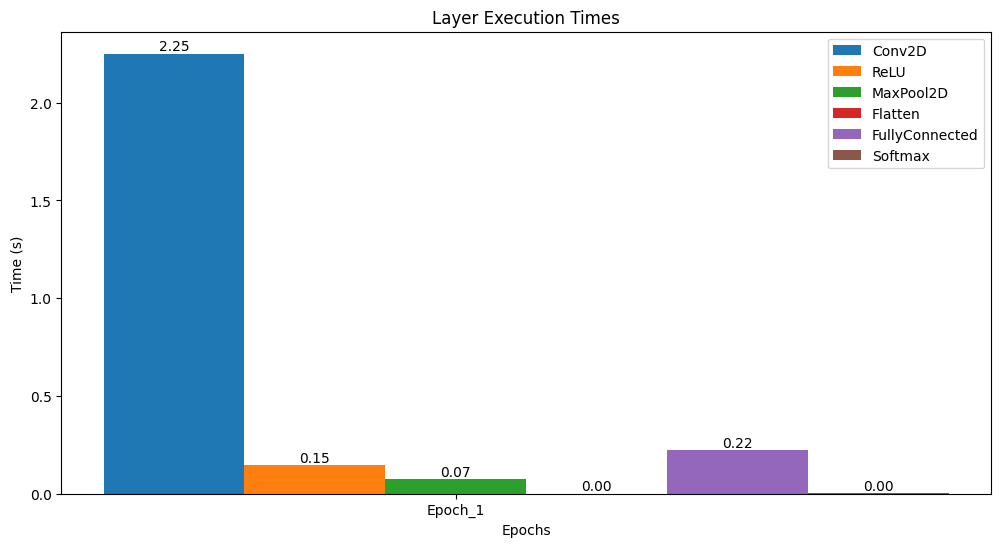

In [50]:
func.plot_details(
    "Data/log/details_log_cuda_10.csv"
)

In [52]:
model_2 = SimpleCNN_CUDA()
train_cuda(
    model_2,
    X_train,
    y_train_onehot,
    epochs=1,        # train thử 1 epoch
    learning_rate=0.001,
    mb_size=64,
    log_filename="Data/log/training_log_cuda_50000.csv",
    detail_log_filename="Data/log/details_log_cuda_50000.csv"
)

KeyboardInterrupt: 